# Deteccion de Señales de Transito

### Integrantes del equipo N° #16:

A00572928 - André Martins Cordebello

A01334976 - Israel Campos Báez

A01166758 - Juan Manuel Carballo Montaño

A01795149 - Kevin Balderas Sánchez

A01793650 - Jessica Paola Pulido Vásquez


### Docentes:

Dr. David Antonio Torres

Dr. Luis Anselmo Fortoul Díaz



**Maestría en Inteligencia Artificial Aplicada**

**MR4010 - Navegación Autónoma**

## Obtencion del Dataset

In [1]:
%%bash
pip install -q kaggle
mkdir -p ~/.kaggle
cp kaggle.json ~/.kaggle
chmod 600 ~/.kaggle/kaggle.json
kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign -p /content

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0



100%|██████████| 612M/612M [00:27<00:00, 23.0MB/s]


In [2]:
import pathlib

# Change accordingly to the path of download
dataset_path = pathlib.Path("/content").with_suffix("")

In [3]:
from zipfile import ZipFile

# Extract the images from the zip file
with ZipFile(dataset_path / "gtsrb-german-traffic-sign.zip") as obj:
    obj.extractall(path=dataset_path / "gtsrb-german-traffic-sign" )

In [1]:
# Import the required libraries
import os
import cv2
import glob
import time
import numpy as np
import pandas as pd
import seaborn as sb
import tensorflow as tf
import matplotlib.pyplot as plt


from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dense, Dropout, Flatten, AveragePooling2D, GlobalAveragePooling2D, Input

## Preprocesamiento

In [5]:
class_df = pd.read_csv(dataset_path / "gtsrb-german-traffic-sign" / "Meta.csv")

class_df.sample(10)

,Path,ClassId,ShapeId,ColorId,SignId
21,Meta/28.png,28,0,0,1.33
2,Meta/1.png,1,1,0,3.29
39,Meta/6.png,6,1,3,3.3
24,Meta/30.png,30,0,0,NaN
38,Meta/5.png,5,1,0,3.29
17,Meta/23.png,23,0,0,1.13
20,Meta/26.png,26,0,0,1.24
41,Meta/8.png,8,1,0,3.29
30,Meta/36.png,36,1,1,4.4
4,Meta/11.png,11,0,0,1.22


Se definen variables globales que afectan al entrenamiento

In [6]:
BATCH_SIZE = 64
BUFFER_SIZE = 64
IM_WIDTH = 256
IM_HEIGHT = 256
TRAIN_VAL_SPLIT_RATIO = 0.15
TRAIN_EPOCHS = 15
CLASSES = sorted(class_df["ClassId"].to_list())
NUM_CLASSES = len(CLASSES)

### Dataset de entrenamiento y validacion

In [7]:
train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    directory=dataset_path / "gtsrb-german-traffic-sign" / "Train",
    validation_split=TRAIN_VAL_SPLIT_RATIO,
    subset='both',
    seed=100,
    labels='inferred',
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=(IM_WIDTH,IM_HEIGHT))

Found 39209 files belonging to 43 classes.
Using 33328 files for training.
Using 5881 files for validation.


In [8]:
preprocessing = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1/255.)

train_ds = train_ds.map(lambda x,y: (preprocessing.standardize(x),y))
val_ds = val_ds.map(lambda x,y: (preprocessing.standardize(x),y))

### Dataset de prueba

In [9]:
test_df = pd.read_csv(dataset_path / "gtsrb-german-traffic-sign" / "Test.csv")

test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12630 entries, 0 to 12629
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Width    12630 non-null  int64 
 1   Height   12630 non-null  int64 
 2   Roi.X1   12630 non-null  int64 
 3   Roi.Y1   12630 non-null  int64 
 4   Roi.X2   12630 non-null  int64 
 5   Roi.Y2   12630 non-null  int64 
 6   ClassId  12630 non-null  int64 
 7   Path     12630 non-null  object
dtypes: int64(7), object(1)
memory usage: 789.5+ KB


In [10]:
def read_test_df(test_df, im_height, im_width, num_classes):
    def generator():
        for i, row in enumerate(test_df['Path'].to_list()):
            image = tf.io.read_file(str(dataset_path / "gtsrb-german-traffic-sign" / row))
            image = tf.io.decode_png(image)
            image = tf.image.convert_image_dtype(image, dtype=tf.float32) / 255.
            image = tf.image.resize_with_pad(image, target_height=im_height, target_width=im_width)
            label = tf.keras.utils.to_categorical(test_df.iloc[i].ClassId, num_classes=num_classes)
            yield image, label
    return generator


test_ds = tf.data.Dataset.from_generator(read_test_df(test_df, IM_HEIGHT, IM_WIDTH, NUM_CLASSES),
                                         output_signature=(
                                             tf.TensorSpec(shape=(IM_HEIGHT, IM_WIDTH, 3), dtype=tf.float32),
                                             tf.TensorSpec(shape=(NUM_CLASSES), dtype=tf.float32))
                                         ).take(512).batch(BATCH_SIZE, drop_remainder=True)

### Visualizacion del Dataset

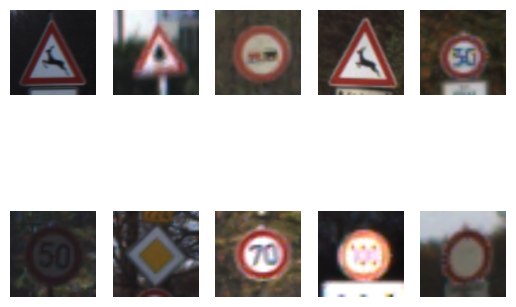

In [11]:
img, label = next(iter(train_ds))

fig, axes = plt.subplots(2, 5)
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(img[i])
    axes[i].set_axis_off()

## Definicion del Modelo

In [12]:
class TrafficNet(tf.keras.models.Model):

    def __init__(self, num_classes, input_shape, *args, **kwargs):
        super(TrafficNet, self).__init__(*args, **kwargs)
        self.raw_shape = input_shape

        self.conv1 = Conv2D(32, (3,3), (1,1), padding='same', activation='relu')
        self.pool1 = MaxPooling2D(pool_size=3, strides=2, padding='same')

        self.conv2 = Conv2D(64, (3,3), (1,1), padding='same', activation='relu')
        self.pool2 = MaxPooling2D(pool_size=3, strides=2, padding='same')

        self.conv3 = Conv2D(128, (3,3), (1,1), padding='same', activation='relu')
        self.pool3 = MaxPooling2D(pool_size=3, strides=2, padding='same')

        self.flatten = Flatten()
        self.dense1 = Dense(256, activation='relu')
        self.dense2 = Dense(128, activation='relu')
        self.dense3 = Dense(num_classes, activation='softmax')
        self.dropout1 = Dropout(0.2)
        self.dropout2 = Dropout(0.5)

    def call(self, inputs, training=False, mask=None):
        # x = self.model(inputs)
        x = self.conv1(inputs)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.pool2(x)
        x = self.conv3(x)
        x = self.pool3(x)
        x = self.flatten(x)
        x = self.dense1(x)
        x = self.dropout1(x, training=training)
        x = self.dense2(x)
        x = self.dropout2(x, training=training)
        x = self.dense3(x)

        return x

    def build_graph(self):
        x = tf.keras.Input(shape=self.raw_shape)
        return tf.keras.Model(inputs=[x], outputs=self.call(x))

In [13]:
model = TrafficNet(num_classes=NUM_CLASSES, input_shape=(IM_HEIGHT, IM_WIDTH, 3))

model.build_graph().summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 256, 256, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 128, 128, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 64, 64, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 64, 64, 128)       73856 

In [14]:
model.compile(loss="binary_crossentropy", metrics = ['accuracy'], optimizer='adam')

model.fit(train_ds, epochs=TRAIN_EPOCHS, validation_data=val_ds)

## Entrenamiento del Modelo

In [15]:
class Trainer(object):

    def __init__(self, epochs, train_dataset, val_dataset, loss_fn, optimizer, train_metric, val_metric) -> None:
        self.epochs = epochs
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.train_metric = train_metric
        self.val_metric = val_metric


    def train(self, model):
        history = {
            'loss': [],
            'val_loss': [],
            'acc': [],
            'val_acc': []
        }
        for epoch in range(self.epochs):
            t = time.time()
            for step, (x_batch_train, y_batch_train) in tqdm(enumerate(self.train_dataset)):
                train_loss_value = self.__train_step(model, x_batch_train, y_batch_train)

            for val_step, (x_batch_val, y_batch_val) in enumerate(self.val_dataset):
                val_loss_value = self.__test_step(model, x_batch_val, y_batch_val)

            template = """ETA: {} - epoch {} loss: {} acc: {} val_loss: {} val_acc: {}\n"""

            print(
                template.format(
                    round((time.time() - t)/60, 2),
                    epoch + 1,
                    train_loss_value,
                    float(self.train_metric.result()),
                    val_loss_value,
                    float(self.val_metric.result())
                )
            )

            history['loss'].append(train_loss_value)
            history['val_loss'].append(val_loss_value)
            history['acc'].append(float(self.train_metric.result()))
            history['val_acc'].append(float(self.val_metric.result()))

            self.train_metric.reset_states()
            self.val_metric.reset_states()

        return history


    @tf.function
    def __train_step(self, model, x_batch, y_batch):
        with tf.GradientTape() as tape:
            logits = model(x_batch, training=True)
            loss_value = self.loss_fn(y_batch, logits)

        grads = tape.gradient(loss_value, model.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, model.trainable_weights))
        self.train_metric.update_state(y_batch, logits)

        return loss_value


    @tf.function
    def __test_step(self, model, x_batch, y_batch):
        val_logits = model(x_batch, training=False)
        val_loss_value = self.loss_fn(y_batch, val_logits)
        self.val_metric.update_state(y_batch, val_logits)

        return val_loss_value

In [16]:
# trainer = Trainer(epochs=TRAIN_EPOCHS,
#                   train_dataset=train_ds,
#                   val_dataset=val_ds,
#                   loss_fn=tf.keras.losses.CategoricalCrossentropy(),
#                   optimizer=tf.keras.optimizers.Adam(),
#                   train_metric=tf.keras.metrics.CategoricalAccuracy(),
#                   val_metric=tf.keras.metrics.CategoricalAccuracy())

# history = trainer.train(model)

521it [00:23, 21.91it/s]


ETA: 0.44 - epoch 1 loss: 1.0177680253982544 acc: 0.4270283281803131 val_loss: 0.8723320364952087 val_acc: 0.7367794513702393



521it [00:14, 35.47it/s]


ETA: 0.27 - epoch 2 loss: 0.461209774017334 acc: 0.7689330577850342 val_loss: 0.24530325829982758 val_acc: 0.9205917119979858



521it [00:14, 35.36it/s]


...

ETA: 0.27 - epoch 13 loss: 0.060016993433237076 acc: 0.9759661555290222 val_loss: 0.2744046151638031 val_acc: 0.9775548577308655



521it [00:14, 35.59it/s]


ETA: 0.27 - epoch 14 loss: 0.13981208205223083 acc: 0.976986289024353 val_loss: 0.1862824559211731 val_acc: 0.9833361506462097



521it [00:14, 35.39it/s]


ETA: 0.27 - epoch 15 loss: 0.11736011505126953 acc: 0.9766562581062317 val_loss: 0.16203148663043976 val_acc: 0.9858867526054382



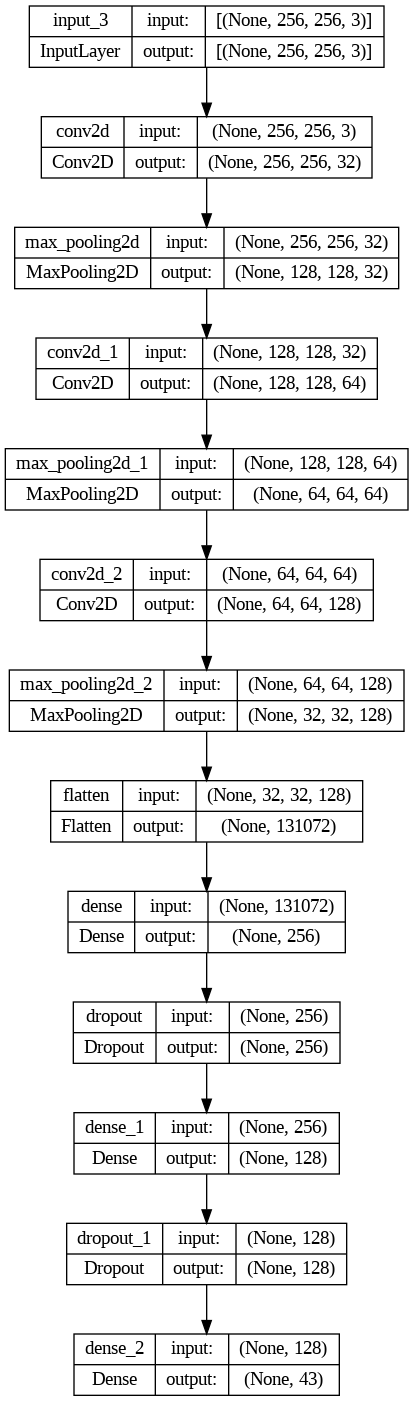

In [24]:
tf.keras.utils.plot_model(
    model.build_graph(),
    show_shapes=True
)

## Verificacion del Modelo

In [17]:
from tqdm import tqdm

y_true = []
y_pred = []
for batch, label in tqdm(test_ds):
    pred = model.predict(batch, verbose=0)
    y_pred.append(np.argmax(pred, axis=1))
    y_true.append(np.argmax(label, axis=1))


8it [00:04,  1.66it/s]


In [18]:
y_true[1], y_pred[1]

(array([15,  9, 26,  2,  5, 28, 11, 25, 30, 34,  5, 12,  1, 10, 25, 25, 21,
        33, 25,  7, 10, 35,  3,  7, 22, 13,  3,  1,  2, 14, 12, 32,  3, 38,
         9, 33,  1, 10,  5, 11, 33,  4, 35, 25, 33,  4,  1, 14, 16, 10, 30,
         3, 27, 29,  1, 17, 13,  7,  1,  8,  2, 10, 10, 30]),
 array([7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
        7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
        7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]))

<Axes: >

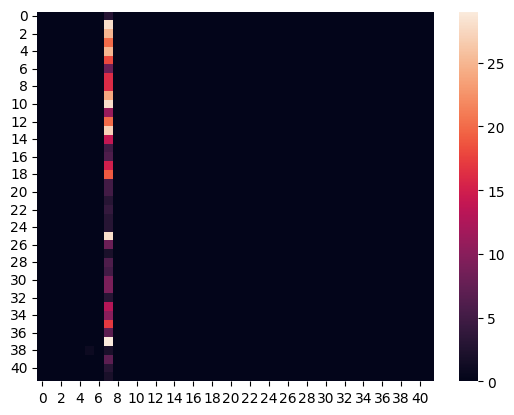

In [19]:
sb.heatmap(confusion_matrix(np.concatenate(y_true), np.concatenate(y_pred)))

Text(0.5, 0, 'epoch')

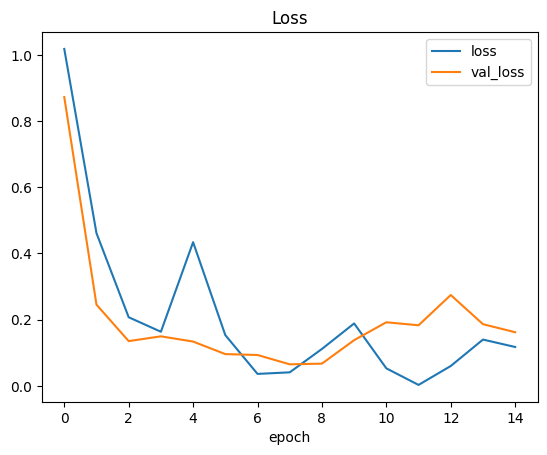

In [20]:
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.title('Loss')
plt.xlabel('epoch')

Text(0.5, 0, 'epoch')

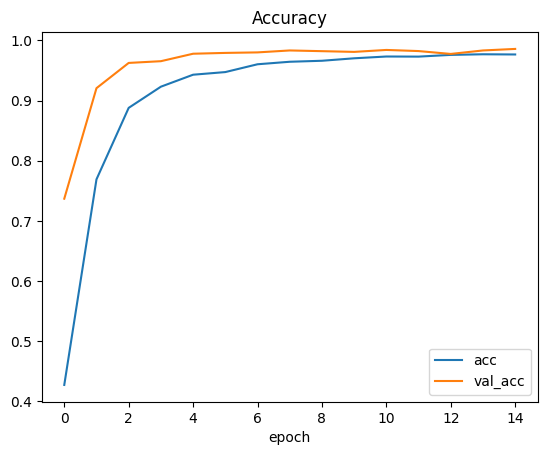

In [21]:
plt.plot(history['acc'])
plt.plot(history['val_acc'])
plt.legend(['acc', 'val_acc'])
plt.title('Accuracy')
plt.xlabel('epoch')

In [22]:
model.save("/content/model.keras")